## PCOS Prediction – A Data Science Capstone Project

Polycystic Ovary Syndrome (PCOS) is a common hormonal condition that can affect women's reproductive health and overall well-being. Early identification of PCOS-related patterns can help in timely medical evaluation and management.

In this project, I developed a **machine learning classification model to predict whether a patient is likely to have PCOS based on various clinical and lifestyle-related features**.

The project includes:

* Data cleaning and preprocessing
* Handling duplicate records
* Encoding categorical variables
* Exploratory Data Analysis (EDA)
* Feature selection
* Feature scaling
* Training multiple machine learning classification models
* Hyperparameter tuning using GridSearchCV
* Model evaluation using accuracy, confusion matrix, classification report, and ROC curve

The final model is used to provide a **PCOS prediction/screening result** based on the available patient features.


In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("PCOS_Dataset.csv")

In [3]:
# Understand the Dataset

In [4]:
df.head()

,Sl. No,Patient File No.,Age,Weight,Height,BMI,Blood Group,Cycle(R/I),FSH,LH,...,AMH(ng/mL),Beta-HCG-I,Beta-HCG-II,Weight Gain,Hair Growth,Pimples,Exercise,Follicle Left,Follicle Right,PCOS (Y/N)
0,1,PF0001,36,69.1,146.0,32.4,B+,Regular,2.34,8.37,...,2.85,476.25,373.03,No,Yes,No,Yes,19.0,12.0,No
1,2,PF0002,37,66.1,155.7,27.3,B+,Irregular,6.57,13.18,...,5.11,220.38,188.25,Yes,Yes,Yes,Yes,13.0,15.0,Yes
2,3,PF0003,27,83.6,161.1,32.2,AB+,Regular,2.65,9.60,...,3.83,79.05,112.93,No,Yes,Yes,Yes,18.0,17.0,No
3,4,PF0004,33,75.3,154.0,31.8,AB+,Regular,7.67,6.86,...,5.80,57.34,387.98,Yes,No,Yes,Yes,6.0,8.0,No
4,5,PF0005,29,65.7,158.0,26.3,B+,Regular,10.65,5.47,...,7.13,330.55,471.57,Yes,Yes,No,No,8.0,20.0,No


In [5]:
df.columns

Index(['Sl. No', 'Patient File No.', 'Age', 'Weight', 'Height', 'BMI',
       'Blood Group', 'Cycle(R/I)', 'FSH', 'LH', 'TSH', 'AMH(ng/mL)',
       'Beta-HCG-I', 'Beta-HCG-II', 'Weight Gain', 'Hair Growth', 'Pimples',
       'Exercise', 'Follicle Left', 'Follicle Right', 'PCOS (Y/N)'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Sl. No            200 non-null    int64  
 1   Patient File No.  200 non-null    object 
 2   Age               200 non-null    int64  
 3   Weight            196 non-null    float64
 4   Height            198 non-null    float64
 5   BMI               199 non-null    float64
 6   Blood Group       200 non-null    object 
 7   Cycle(R/I)        199 non-null    object 
 8   FSH               198 non-null    float64
 9   LH                200 non-null    float64
 10  TSH               194 non-null    float64
 11  AMH(ng/mL)        198 non-null    float64
 12  Beta-HCG-I        200 non-null    float64
 13  Beta-HCG-II       198 non-null    float64
 14  Weight Gain       197 non-null    object 
 15  Hair Growth       199 non-null    object 
 16  Pimples           195 non-null    object 
 1

In [7]:
df.describe()

,Sl. No,Age,Weight,Height,BMI,FSH,LH,TSH,AMH(ng/mL),Beta-HCG-I,Beta-HCG-II,Follicle Left,Follicle Right
count,200.00000,200.000000,196.000000,198.000000,199.000000,198.000000,200.000000,194.000000,198.000000,200.000000,198.000000,198.000000,199.000000
mean,95.62500,29.545000,70.544898,159.408586,28.045729,7.030808,8.299200,3.530206,5.321818,249.085300,264.398131,12.222222,11.804020
std,57.67248,6.759915,13.492175,8.554696,6.219996,2.898302,3.622956,1.455268,2.555101,145.991551,144.221719,4.873122,5.005732
min,1.00000,18.000000,45.300000,145.300000,15.000000,2.020000,2.180000,1.090000,1.030000,6.650000,5.040000,4.000000,4.000000
25%,45.75000,24.000000,61.275000,152.350000,23.550000,4.552500,4.880000,2.205000,3.082500,122.987500,146.680000,8.000000,7.000000
50%,95.50000,30.000000,68.750000,159.050000,27.400000,7.405000,8.205000,3.550000,5.150000,242.615000,272.230000,13.000000,12.000000
75%,145.25000,36.000000,82.825000,166.600000,32.700000,9.577500,11.567500,4.897500,7.525000,376.720000,393.800000,16.750000,16.000000
max,195.00000,40.000000,94.100000,175.000000,42.400000,11.930000,14.790000,6.000000,9.990000,496.190000,499.850000,20.000000,20.000000


In [8]:
df.isnull().sum()

Sl. No              0
Patient File No.    0
Age                 0
Weight              4
Height              2
BMI                 1
Blood Group         0
Cycle(R/I)          1
FSH                 2
LH                  0
TSH                 6
AMH(ng/mL)          2
Beta-HCG-I          0
Beta-HCG-II         2
Weight Gain         3
Hair Growth         1
Pimples             5
Exercise            3
Follicle Left       2
Follicle Right      1
PCOS (Y/N)          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(5)

In [10]:
df[df.duplicated()]

,Sl. No,Patient File No.,Age,Weight,Height,BMI,Blood Group,Cycle(R/I),FSH,LH,...,AMH(ng/mL),Beta-HCG-I,Beta-HCG-II,Weight Gain,Hair Growth,Pimples,Exercise,Follicle Left,Follicle Right,PCOS (Y/N)
195,1,PF0001,36,69.1,146.0,32.4,B+,Regular,2.34,8.37,...,2.85,476.25,373.03,No,Yes,No,Yes,19.0,12.0,No
196,2,PF0002,37,66.1,155.7,27.3,B+,Irregular,6.57,13.18,...,5.11,220.38,188.25,Yes,Yes,Yes,Yes,13.0,15.0,Yes
197,3,PF0003,27,83.6,161.1,32.2,AB+,Regular,2.65,9.60,...,3.83,79.05,112.93,No,Yes,Yes,Yes,18.0,17.0,No
198,4,PF0004,33,75.3,154.0,31.8,AB+,Regular,7.67,6.86,...,5.80,57.34,387.98,Yes,No,Yes,Yes,6.0,8.0,No
199,5,PF0005,29,65.7,158.0,26.3,B+,Regular,10.65,5.47,...,7.13,330.55,471.57,Yes,Yes,No,No,8.0,20.0,No


In [11]:
df.drop_duplicates(inplace=True)

# Keep Patient ID separately for final prediction
patient_ids = df['Patient File No.'].copy()

# Remove ID columns from ML features
df.drop(['Sl. No','Patient File No.'],axis=1,inplace=True)

In [12]:
#Handle Missing Values
#Numerical Columns
#Fill with Median

In [13]:
import numpy as np

In [14]:
numerical_columns=df.select_dtypes(include=np.number).columns

for col in numerical_columns:
    df[col].fillna(df[col].median(),inplace=True)

C:\Users\prave\AppData\Local\Temp\ipykernel_10944\2376555006.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(),inplace=True)


In [15]:
#Categorical Columns
#Fill with Mode

In [16]:
categorical_columns=df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col].fillna(df[col].mode()[0],inplace=True)

C:\Users\prave\AppData\Local\Temp\ipykernel_10944\4175112100.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0],inplace=True)


In [17]:
df.isnull().sum()

Age               0
Weight            0
Height            0
BMI               0
Blood Group       0
Cycle(R/I)        0
FSH               0
LH                0
TSH               0
AMH(ng/mL)        0
Beta-HCG-I        0
Beta-HCG-II       0
Weight Gain       0
Hair Growth       0
Pimples           0
Exercise          0
Follicle Left     0
Follicle Right    0
PCOS (Y/N)        0
dtype: int64

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 195 entries, 0 to 194
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             195 non-null    int64  
 1   Weight          195 non-null    float64
 2   Height          195 non-null    float64
 3   BMI             195 non-null    float64
 4   Blood Group     195 non-null    object 
 5   Cycle(R/I)      195 non-null    object 
 6   FSH             195 non-null    float64
 7   LH              195 non-null    float64
 8   TSH             195 non-null    float64
 9   AMH(ng/mL)      195 non-null    float64
 10  Beta-HCG-I      195 non-null    float64
 11  Beta-HCG-II     195 non-null    float64
 12  Weight Gain     195 non-null    object 
 13  Hair Growth     195 non-null    object 
 14  Pimples         195 non-null    object 
 15  Exercise        195 non-null    object 
 16  Follicle Left   195 non-null    float64
 17  Follicle Right  195 non-null    float64


In [19]:
# Encode Categorical Columns

In [20]:
df.select_dtypes(include='object').columns

Index(['Blood Group', 'Cycle(R/I)', 'Weight Gain', 'Hair Growth', 'Pimples',
       'Exercise', 'PCOS (Y/N)'],
      dtype='object')

In [21]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col]=le.fit_transform(df[col])

# Exploratory Data Analysis (EDA)

In [22]:
#Target Distribution

In [23]:
import matplotlib.pyplot as plt   # Create basic plots
import seaborn as sns

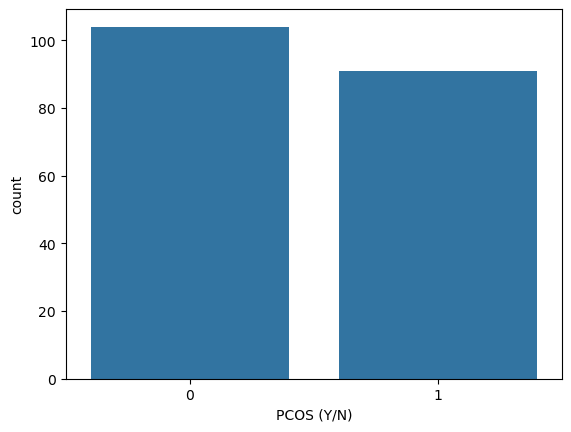

In [24]:
sns.countplot(x='PCOS (Y/N)',data=df)
plt.show()

In [25]:
#Correlation

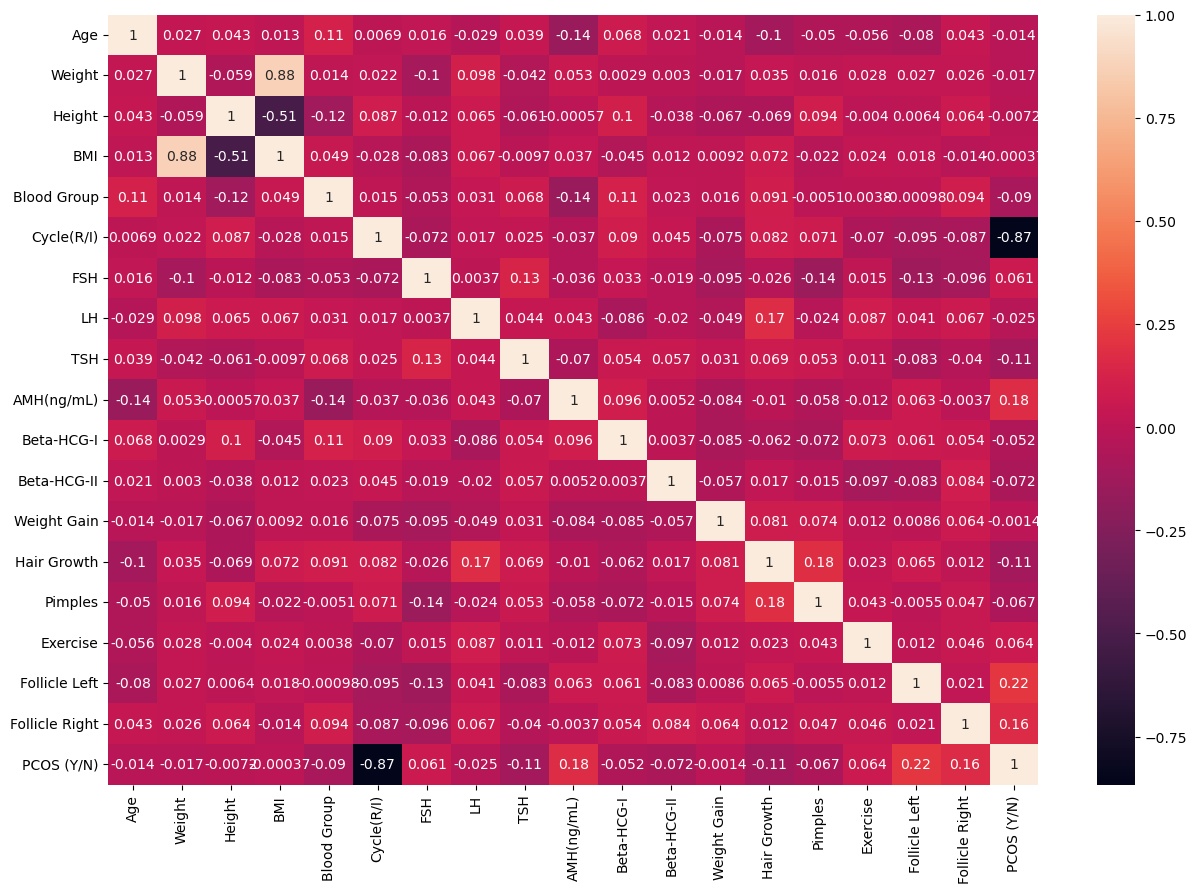

In [26]:
plt.figure(figsize=(15,10))

sns.heatmap(df.corr(),annot=True)

plt.show()

In [27]:
#Histogram

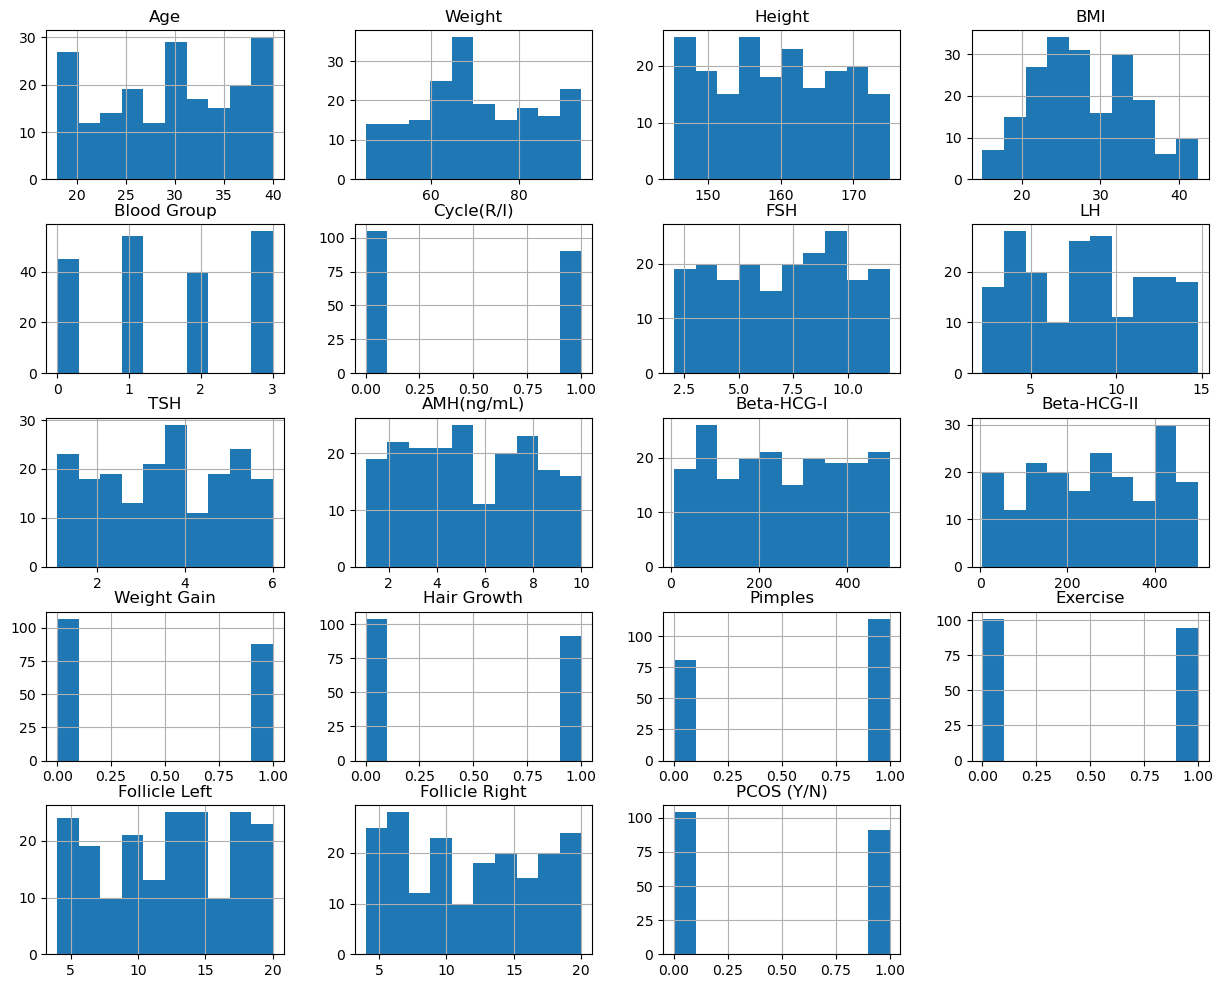

In [28]:
df.hist(figsize=(15,12))
plt.show()

In [29]:
#Box plot

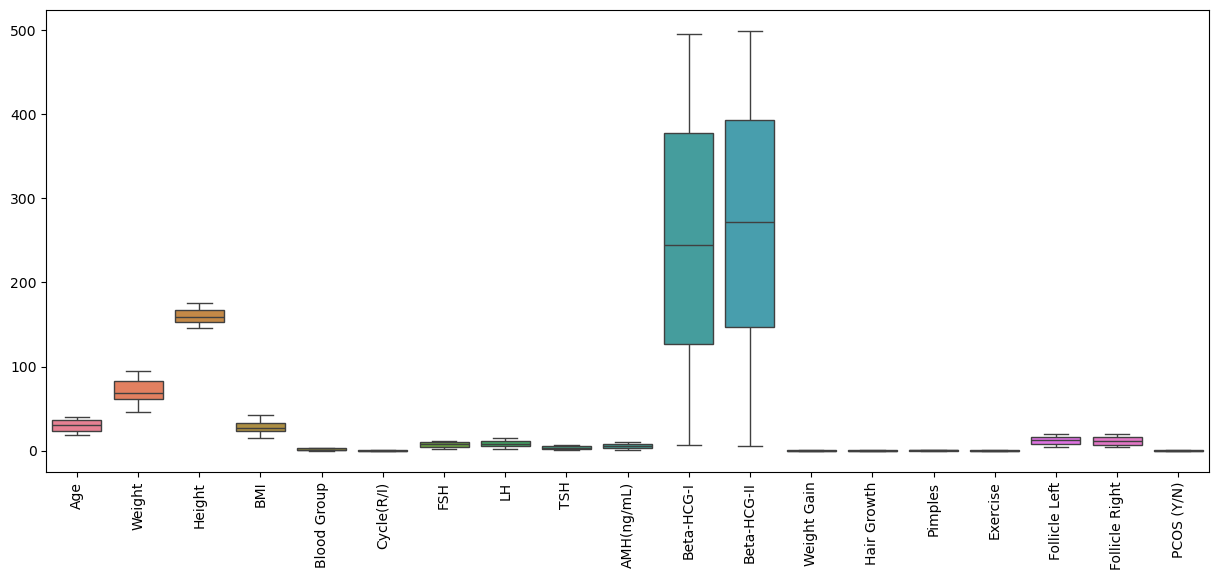

In [30]:
plt.figure(figsize=(15,6))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()

In [31]:
#Feature & Target

In [32]:
X=df.drop('PCOS (Y/N)',axis=1)

y=df['PCOS (Y/N)']

In [33]:
#Step 13: Train Test Split

In [34]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [35]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 10 features
selector = SelectKBest(score_func=f_classif, k=10)

# Fit feature selection only on training data
X_train_selected = selector.fit_transform(X_train, y_train)

# Transform test data using the same selector
X_test_selected = selector.transform(X_test)

print("Original number of features:", X_train.shape[1])
print("Selected number of features:", X_train_selected.shape[1])

Original number of features: 18
Selected number of features: 10


In [36]:
selected_features = X.columns[selector.get_support()]

print("Selected Features:")
print(selected_features.tolist())

Selected Features:
['BMI', 'Cycle(R/I)', 'FSH', 'TSH', 'AMH(ng/mL)', 'Beta-HCG-II', 'Hair Growth', 'Exercise', 'Follicle Left', 'Follicle Right']


In [37]:
#Feature Scaling

In [38]:
from sklearn.preprocessing import StandardScaler

sc=StandardScaler()

X_train=sc.fit_transform(X_train)

X_test=sc.transform(X_test)

In [39]:
#Train Models.

In [40]:
#Import Models

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [42]:
#Step 16: Store Models in a Dictionary

In [43]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

In [44]:


#Train All Models

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
SVM trained successfully.
KNN trained successfully.
Naive Bayes trained successfully.


In [45]:
#Predication

from sklearn.metrics import accuracy_score

for name, model in models.items():

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(f"{name} Accuracy : {accuracy:.2f}")

Logistic Regression Accuracy : 0.92
Decision Tree Accuracy : 0.95
Random Forest Accuracy : 0.95
SVM Accuracy : 0.92
KNN Accuracy : 0.85
Naive Bayes Accuracy : 0.92


In [46]:
#confusion matrix

from sklearn.metrics import confusion_matrix

for name, model in models.items():

    y_pred = model.predict(X_test)

    print(f"\n{name}")

    print(confusion_matrix(y_test, y_pred))


Logistic Regression
[[17  3]
 [ 0 19]]

Decision Tree
[[18  2]
 [ 0 19]]

Random Forest
[[18  2]
 [ 0 19]]

SVM
[[17  3]
 [ 0 19]]

KNN
[[17  3]
 [ 3 16]]

Naive Bayes
[[17  3]
 [ 0 19]]


In [47]:
#Classification Report

from sklearn.metrics import classification_report

for name, model in models.items():

    y_pred = model.predict(X_test)

    print(f"\n{name}")

    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.85      0.92        20
           1       0.86      1.00      0.93        19

    accuracy                           0.92        39
   macro avg       0.93      0.93      0.92        39
weighted avg       0.93      0.92      0.92        39


Decision Tree
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        20
           1       0.90      1.00      0.95        19

    accuracy                           0.95        39
   macro avg       0.95      0.95      0.95        39
weighted avg       0.95      0.95      0.95        39


Random Forest
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        20
           1       0.90      1.00      0.95        19

    accuracy                           0.95        39
   macro avg       0.95      0.95      0.95        39
weighted avg       0.95

In [48]:
#Accuracy Comparison Table

accuracy = []

model_name = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    model_name.append(name)

    accuracy.append(acc)

result = pd.DataFrame({"Model": model_name,"Accuracy": accuracy})

result

,Model,Accuracy
0,Logistic Regression,0.923077
1,Decision Tree,0.948718
2,Random Forest,0.948718
3,SVM,0.923077
4,KNN,0.846154
5,Naive Bayes,0.923077


In [49]:
#Best model

result.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
1,Decision Tree,0.948718
2,Random Forest,0.948718
0,Logistic Regression,0.923077
3,SVM,0.923077
5,Naive Bayes,0.923077
4,KNN,0.846154


In [50]:
#Feature selection

In [51]:
#1. K-Best Feature Selection

In [52]:

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

selector = SelectKBest(score_func=f_classif, k=5)

X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print(selected_features)

Index(['Cycle(R/I)', 'TSH', 'AMH(ng/mL)', 'Follicle Left', 'Follicle Right'], dtype='object')


In [53]:
#2. Recursive Feature Elimination (RFE)

In [54]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

rfe = RFE(estimator=model, n_features_to_select=5)

X_rfe = rfe.fit_transform(X, y)

selected_features = X.columns[rfe.support_]

print(selected_features)

C:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentati

Index(['Cycle(R/I)', 'TSH', 'AMH(ng/mL)', 'Weight Gain', 'Hair Growth'], dtype='object')


In [55]:
#PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print(X_pca.shape)

(195, 2)


In [56]:
print(pca.explained_variance_ratio_)

[0.50245882 0.48761011]


In [57]:
#LDA

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=1)

X_lda = lda.fit_transform(X, y)

print(X_lda.shape)

(195, 1)


In [58]:
#Grid Search (Hyperparameter Tuning)

In [59]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

parameters = {'n_estimators':[50,100,150],'max_depth':[3,5,7,None],'criterion':['gini','entropy']}

grid = GridSearchCV(RandomForestClassifier(random_state=42),parameters,cv=5,scoring='accuracy')

grid.fit(X_train,y_train)

print(grid.best_params_)
print(grid.best_score_)

{'criterion': 'gini', 'max_depth': 5, 'n_estimators': 50}
0.955241935483871


In [60]:
#Train Best Model
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

In [61]:
#Accuracy
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.9487179487179487

In [62]:
#6. ROC Curve
from sklearn.metrics import roc_curve,auc

y_prob = best_model.predict_proba(X_test)[:,1]

fpr,tpr,threshold = roc_curve(y_test,y_prob)

roc_auc = auc(fpr,tpr)

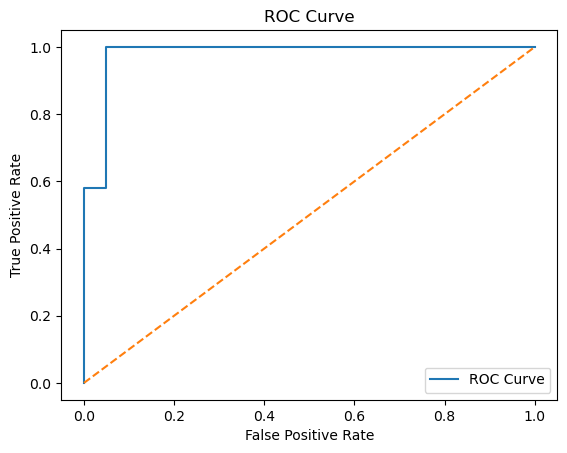

In [63]:
#Plot ROC

plt.plot(fpr,tpr,label="ROC Curve")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [64]:
#Auc Score

print("AUC Score :",roc_auc)

AUC Score : 0.9789473684210526


In [65]:
#Save Model Using Joblib
import joblib

joblib.dump(best_model,"PCOS_Model.pkl")

['PCOS_Model.pkl']

In [66]:
#Load Model
model = joblib.load("PCOS_Model.pkl")

In [67]:
#Predict New Data

prediction = model.predict(X_test[0].reshape(1, -1))

print("Predicted PCOS:", prediction[0])
print("Actual PCOS:", y_test.iloc[0])

Predicted PCOS: 1
Actual PCOS: 1


In [68]:
predictions = model.predict(X_test[:10])

print("Predicted:", predictions)
print("Actual:", y_test.iloc[:10].values)

Predicted: [1 0 0 0 0 1 0 1 0 1]
Actual: [1 0 0 0 0 1 0 1 0 1]


In [69]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": model.predict(X_test)
})

comparison.head(10)

,Actual,Predicted
0,1,1
1,0,0
2,0,0
3,0,0
4,0,0
5,1,1
6,0,0
7,1,1
8,0,0
9,1,1


In [70]:
predictions

array([1, 0, 0, 0, 0, 1, 0, 1, 0, 1])

In [71]:
y_pred = best_model.predict(X_test)

In [72]:
# Final prediction result

result = pd.DataFrame({
    'Patient ID': patient_ids.loc[y_test.index].values,
    'Prediction': y_pred
})

# Convert 0 and 1 into understandable words
result['PCOS Status'] = result['Prediction'].map({
    0: 'No PCOS detected',
    1: 'PCOS detected'
})

# Display final result
result = result[['Patient ID', 'PCOS Status']]

print(result)

   Patient ID       PCOS Status
0      PF0139     PCOS detected
1      PF0017  No PCOS detected
2      PF0156  No PCOS detected
3      PF0097  No PCOS detected
4      PF0069  No PCOS detected
5      PF0154     PCOS detected
6      PF0056  No PCOS detected
7      PF0016     PCOS detected
8      PF0113  No PCOS detected
9      PF0112     PCOS detected
10     PF0185  No PCOS detected
11     PF0019     PCOS detected
12     PF0083  No PCOS detected
13     PF0010     PCOS detected
14     PF0165     PCOS detected
15     PF0118     PCOS detected
16     PF0070     PCOS detected
17     PF0114  No PCOS detected
18     PF0193     PCOS detected
19     PF0120  No PCOS detected
20     PF0124     PCOS detected
21     PF0145     PCOS detected
22     PF0067  No PCOS detected
23     PF0046  No PCOS detected
24     PF0159  No PCOS detected
25     PF0116     PCOS detected
26     PF0068     PCOS detected
27     PF0094  No PCOS detected
28     PF0031     PCOS detected
29     PF0102     PCOS detected
30     P